In [8]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from IPython.display import clear_output
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"  #

In [ ]:

# Plotting callback

class PlotLosses(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.accuracies = []
        self.val_accuracies = []
        
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.accuracies.append(logs.get('accuracy'))
        self.val_accuracies.append(logs.get('val_accuracy'))
        self.i += 1
        
        clear_output(wait=True)
        
        # Plot loss
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(self.x, self.losses, label="loss")
        plt.plot(self.x, self.val_losses, label="val_loss")
        plt.legend()
        plt.title('Loss')
        
        # Plot accuracy
        plt.subplot(1, 2, 2)
        plt.plot(self.x, self.accuracies, label="accuracy")
        plt.plot(self.x, self.val_accuracies, label="val_accuracy")
        plt.legend()
        plt.title('Accuracy')
        
        plt.show()

plot_losses = PlotLosses()

In [4]:
# Define paths
train_dir = './dataset'

# Image data generator
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 60),
    batch_size=64,
    class_mode='categorical',
    subset='training',
    color_mode="grayscale"
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 60),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    color_mode="grayscale"
)

Found 2686 images belonging to 3 classes.
Found 670 images belonging to 3 classes.


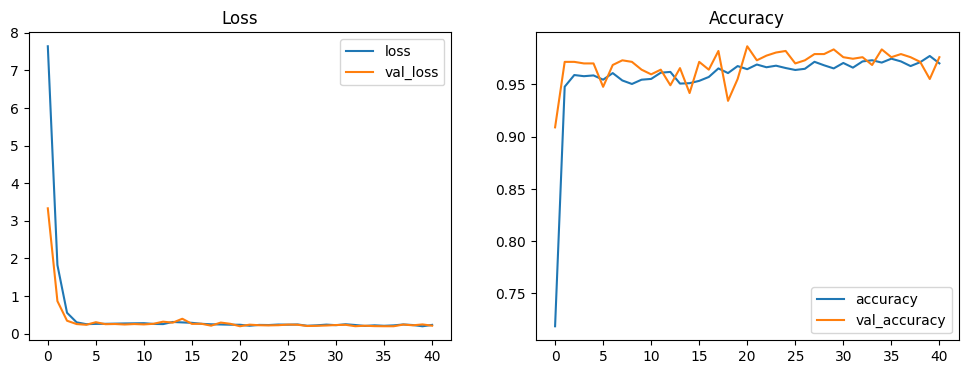

In [ ]:
l2=tf.keras.regularizers.L2(l2=0.01)

# Build the model
model = Sequential([
    Conv2D(32, (3, 3), activation='tanh', input_shape=(150, 60, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='tanh'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='tanh'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='tanh', kernel_regularizer=l2),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=500,
    verbose=0,
    validation_data=validation_generator,
    callbacks=[early_stopping, plot_losses]
)

In [7]:
# Print learning summary
print("Training Summary:")
best_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1
print(f"Best epoch: {best_epoch}")
print(f"Best training loss: {np.min(history.history['loss'])}")
print(f"Best training accuracy: {np.max(history.history['accuracy'])}")
print(f"Best validation loss: {history.history['val_loss'][best_epoch]}")
print(f"Best validation accuracy: {history.history['val_accuracy'][best_epoch]}")

Training Summary:
Best epoch: 21
Best training loss: 0.1934497207403183
Best training accuracy: 0.9772896766662598
Best validation loss: 0.23631630837917328
Best validation accuracy: 0.9731343388557434


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 58, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 5, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     5,571,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,995,851 (64.83 MB)

 Trainable params: 5,665,283 (21.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,330,568 (43.22 MB)

In [10]:
# Define paths
train_dir = './dataset'

# Image data generator without validation split
k_fold_datagen = ImageDataGenerator(rescale=1./255)

k_fold_generator = k_fold_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 60),
    batch_size=64,
    class_mode='categorical',
    color_mode="grayscale"
)

print(len(k_fold_generator.filenames))


Found 3356 images belonging to 3 classes.
3356


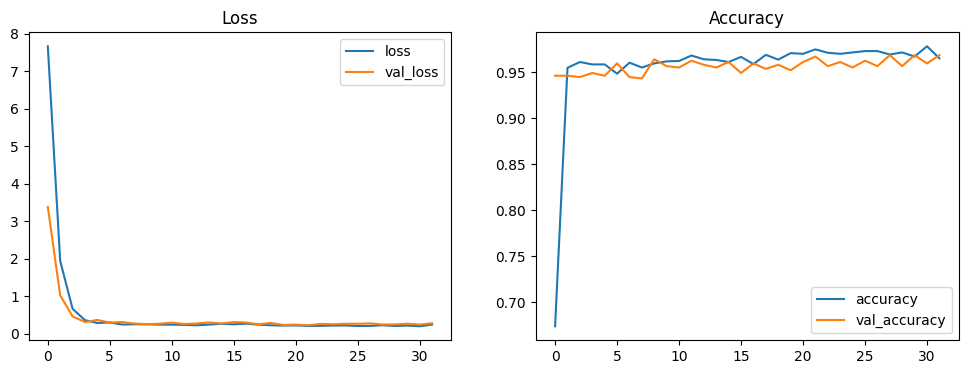

Fold 5 - Best validation loss: 0.2319212406873703, Best validation accuracy: 0.9687034487724304


In [ ]:


# Define the number of folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store results
fold_no = 1
histories = []
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Perform K-Fold Cross Validation
for train_index, val_index in kf.split(np.arange(len(k_fold_generator.filenames))):
    print(f"Training fold {fold_no}...")
    
    # Create a new model instance
    l2=tf.keras.regularizers.L2(l2=0.01)

    # Build the model
    model = Sequential([
        Conv2D(32, (3, 3), activation='tanh', input_shape=(150, 60, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='tanh'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='tanh'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation='tanh', kernel_regularizer=l2),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Create data generators for the current fold
    train_data = np.array(k_fold_generator.filenames)[train_index]
    val_data = np.array(k_fold_generator.filenames)[val_index]
    
    train_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': train_data, 'class': [str(k_fold_generator.classes[i]) for i in train_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    val_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': val_data, 'class': [str(k_fold_generator.classes[i]) for i in val_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    # Train the model
    history = model.fit(
        train_fold_generator,
        epochs=500,
        verbose=0,
        validation_data=val_fold_generator,
        callbacks=[early_stopping, plot_losses]
    )
    
    # Store the history
    histories.append(history)
    
    # Print fold results
    print(f"Fold {fold_no} - Best validation loss: {np.min(history.history['val_loss'])}, Best validation accuracy: {np.max(history.history['val_accuracy'])}")
    
    fold_no += 1


Fold 1 - Best validation loss: 0.2021760493516922, Best validation accuracy: 0.9791666865348816
Fold 2 - Best validation loss: 0.19835972785949707, Best validation accuracy: 0.9746646881103516
Fold 3 - Best validation loss: 0.18538537621498108, Best validation accuracy: 0.9791356325149536
Fold 4 - Best validation loss: 0.17268100380897522, Best validation accuracy: 0.992548406124115
Fold 5 - Best validation loss: 0.2319212406873703, Best validation accuracy: 0.9687034487724304
Mean validation loss: 0.19810467958450317, Std validation loss: 0.019841093086686565
Mean validation accuracy: 0.9788437724113465, Std validation accuracy: 0.007852354425892775


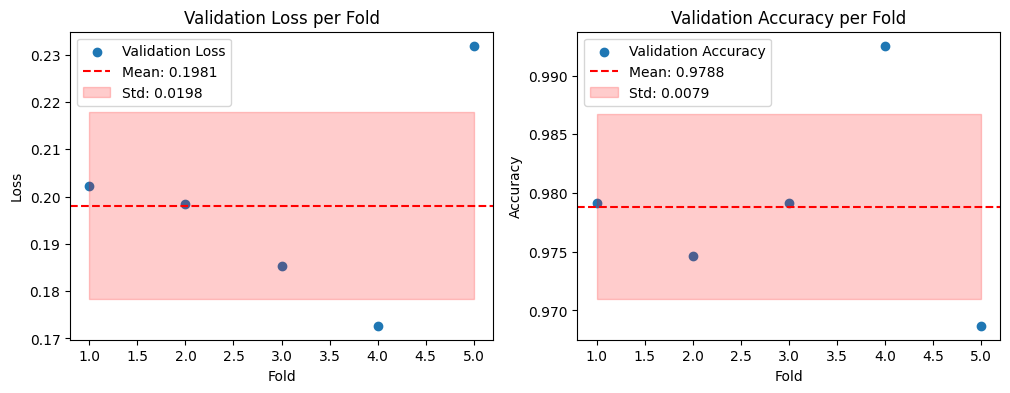

In [16]:
# Initialize lists to store the metrics
val_losses = []
val_accuracies = []

# Iterate through the histories and extract the metrics
for i, history in enumerate(histories):
    val_losses.append(np.min(history.history['val_loss']))
    val_accuracies.append(np.max(history.history['val_accuracy']))
    print(f"Fold {i+1} - Best validation loss: {val_losses[-1]}, Best validation accuracy: {val_accuracies[-1]}")

# Calculate mean and standard deviation
mean_val_loss = np.mean(val_losses)
std_val_loss = np.std(val_losses)
mean_val_accuracy = np.mean(val_accuracies)
std_val_accuracy = np.std(val_accuracies)

# Print mean and standard deviation
print(f"Mean validation loss: {mean_val_loss}, Std validation loss: {std_val_loss}")
print(f"Mean validation accuracy: {mean_val_accuracy}, Std validation accuracy: {std_val_accuracy}")

# Plot the metrics
plt.figure(figsize=(12, 4))

# Plot validation loss
plt.subplot(1, 2, 1)
plt.scatter(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.axhline(mean_val_loss, color='r', linestyle='--', label=f'Mean: {mean_val_loss:.4f}')
plt.fill_between(range(1, len(val_losses) + 1), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='r', alpha=0.2, label=f'Std: {std_val_loss:.4f}')
plt.title('Validation Loss per Fold')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.legend()

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.scatter(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.axhline(mean_val_accuracy, color='r', linestyle='--', label=f'Mean: {mean_val_accuracy:.4f}')
plt.fill_between(range(1, len(val_accuracies) + 1), mean_val_accuracy - std_val_accuracy, mean_val_accuracy + std_val_accuracy, color='r', alpha=0.2, label=f'Std: {std_val_accuracy:.4f}')
plt.title('Validation Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### test with relu instead of tanh

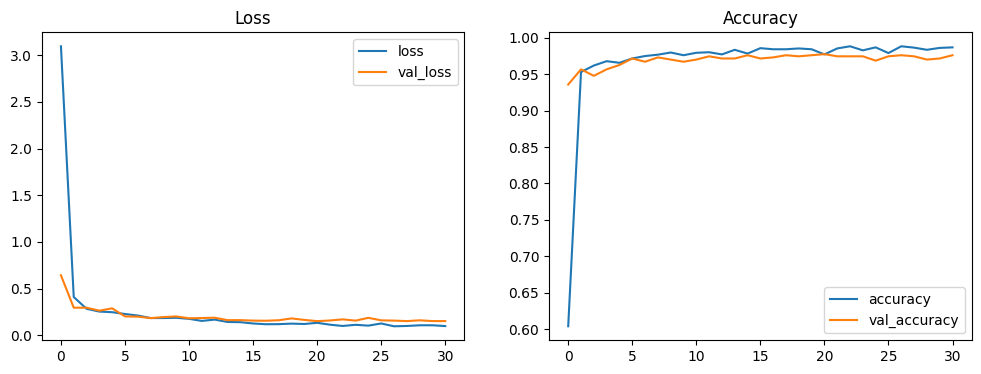

Fold 5 - Best validation loss: 0.1506841778755188, Best validation accuracy: 0.9776452779769897


In [11]:
# Define the number of folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store results
fold_no = 1
histories = []
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Perform K-Fold Cross Validation
for train_index, val_index in kf.split(np.arange(len(k_fold_generator.filenames))):
    print(f"Training fold {fold_no}...")
    
    # Create a new model instance
    l2=tf.keras.regularizers.L2(l2=0.01)

    # Build the model
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(150, 60, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Create data generators for the current fold
    train_data = np.array(k_fold_generator.filenames)[train_index]
    val_data = np.array(k_fold_generator.filenames)[val_index]
    
    train_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': train_data, 'class': [str(k_fold_generator.classes[i]) for i in train_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    val_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': val_data, 'class': [str(k_fold_generator.classes[i]) for i in val_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    # Train the model
    history = model.fit(
        train_fold_generator,
        epochs=500,
        verbose=0,
        validation_data=val_fold_generator,
        callbacks=[early_stopping, plot_losses]
    )
    
    # Store the history
    histories.append(history)
    
    # Print fold results
    print(f"Fold {fold_no} - Best validation loss: {np.min(history.history['val_loss'])}, Best validation accuracy: {np.max(history.history['val_accuracy'])}")
    
    fold_no += 1


Fold 1 - Best validation loss: 0.13160058856010437, Best validation accuracy: 0.9851190447807312
Fold 2 - Best validation loss: 0.09610981494188309, Best validation accuracy: 0.992548406124115
Fold 3 - Best validation loss: 0.1427905112504959, Best validation accuracy: 0.9806259274482727
Fold 4 - Best validation loss: 0.07746735960245132, Best validation accuracy: 0.9940387606620789
Fold 5 - Best validation loss: 0.1506841778755188, Best validation accuracy: 0.9776452779769897
Mean validation loss: 0.1197304904460907, Std validation loss: 0.02819540066818098
Mean validation accuracy: 0.9859954833984375, Std validation accuracy: 0.006433681865330972


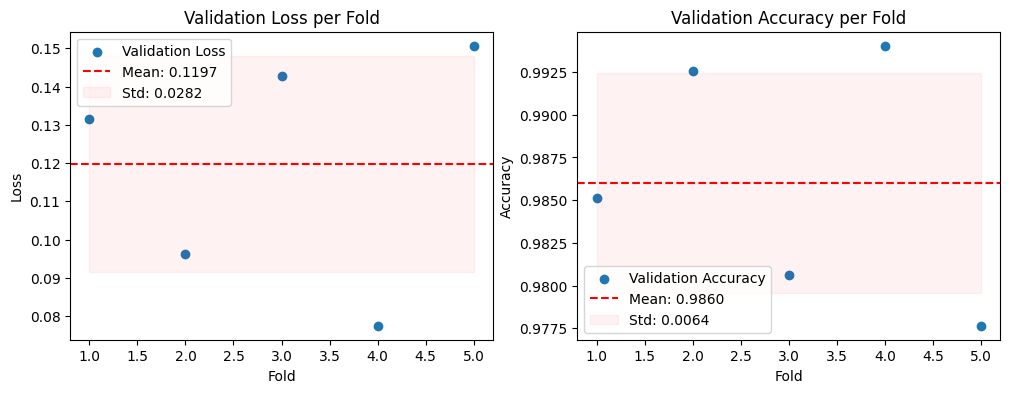

In [13]:
# Initialize lists to store the metrics
val_losses = []
val_accuracies = []

# Iterate through the histories and extract the metrics
for i, history in enumerate(histories):
    val_losses.append(np.min(history.history['val_loss']))
    val_accuracies.append(np.max(history.history['val_accuracy']))
    print(f"Fold {i+1} - Best validation loss: {val_losses[-1]}, Best validation accuracy: {val_accuracies[-1]}")

# Calculate mean and standard deviation
mean_val_loss = np.mean(val_losses)
std_val_loss = np.std(val_losses)
mean_val_accuracy = np.mean(val_accuracies)
std_val_accuracy = np.std(val_accuracies)

# Print mean and standard deviation
print(f"Mean validation loss: {mean_val_loss}, Std validation loss: {std_val_loss}")
print(f"Mean validation accuracy: {mean_val_accuracy}, Std validation accuracy: {std_val_accuracy}")

# Plot the metrics
plt.figure(figsize=(12, 4))

# Plot validation loss
plt.subplot(1, 2, 1)
plt.scatter(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.axhline(mean_val_loss, color='r', linestyle='--', label=f'Mean: {mean_val_loss:.4f}')
plt.fill_between(range(1, len(val_losses) + 1), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='r', alpha=0.05, label=f'Std: {std_val_loss:.4f}')
plt.title('Validation Loss per Fold')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.legend(loc='upper left')

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.scatter(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.axhline(mean_val_accuracy, color='r', linestyle='--', label=f'Mean: {mean_val_accuracy:.4f}')
plt.fill_between(range(1, len(val_accuracies) + 1), mean_val_accuracy - std_val_accuracy, mean_val_accuracy + std_val_accuracy, color='r', alpha=0.05, label=f'Std: {std_val_accuracy:.4f}')
plt.title('Validation Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend(loc='lower left')

plt.show()

### Test different kernel regularizers

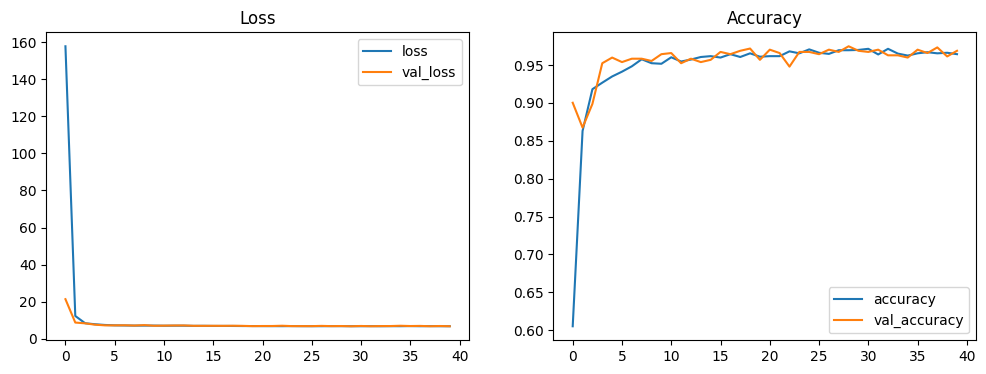

Fold 5 - Best validation loss: 6.817627429962158, Best validation accuracy: 0.9746646881103516


In [22]:
# Define the number of folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store results
fold_no = 1
histories = []
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Perform K-Fold Cross Validation
for train_index, val_index in kf.split(np.arange(len(k_fold_generator.filenames))):
    print(f"Training fold {fold_no}...")
    
    # Create a new model instance
    l1=tf.keras.regularizers.L1(l1=0.01)

    # Build the model
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(150, 60, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l1),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Create data generators for the current fold
    train_data = np.array(k_fold_generator.filenames)[train_index]
    val_data = np.array(k_fold_generator.filenames)[val_index]
    
    train_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': train_data, 'class': [str(k_fold_generator.classes[i]) for i in train_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    val_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': val_data, 'class': [str(k_fold_generator.classes[i]) for i in val_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    # Train the model
    history = model.fit(
        train_fold_generator,
        epochs=500,
        verbose=0,
        validation_data=val_fold_generator,
        callbacks=[early_stopping, plot_losses]
    )
    
    # Store the history
    histories.append(history)
    
    # Print fold results
    print(f"Fold {fold_no} - Best validation loss: {np.min(history.history['val_loss'])}, Best validation accuracy: {np.max(history.history['val_accuracy'])}")
    
    fold_no += 1

Fold 1 - Best validation loss: 6.828182220458984, Best validation accuracy: 0.980654776096344
Fold 2 - Best validation loss: 6.720698833465576, Best validation accuracy: 0.9880775213241577
Fold 3 - Best validation loss: 6.926276683807373, Best validation accuracy: 0.9791356325149536
Fold 4 - Best validation loss: 6.828146934509277, Best validation accuracy: 0.9880775213241577
Fold 5 - Best validation loss: 6.817627429962158, Best validation accuracy: 0.9746646881103516
Mean validation loss: 6.8241864204406735, Std validation loss: 0.06512568614269121
Mean validation accuracy: 0.9821220278739929, Std validation accuracy: 0.005246315008456955


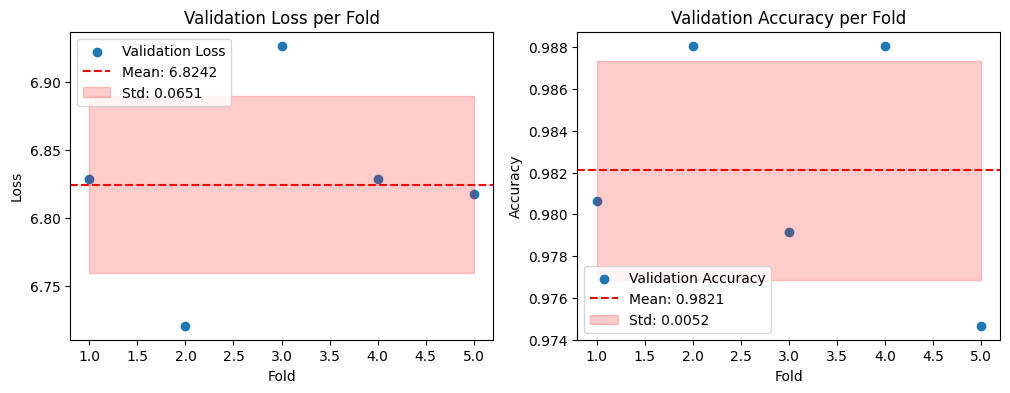

In [23]:
# Initialize lists to store the metrics
val_losses = []
val_accuracies = []

# Iterate through the histories and extract the metrics
for i, history in enumerate(histories):
    val_losses.append(np.min(history.history['val_loss']))
    val_accuracies.append(np.max(history.history['val_accuracy']))
    print(f"Fold {i+1} - Best validation loss: {val_losses[-1]}, Best validation accuracy: {val_accuracies[-1]}")

# Calculate mean and standard deviation
mean_val_loss = np.mean(val_losses)
std_val_loss = np.std(val_losses)
mean_val_accuracy = np.mean(val_accuracies)
std_val_accuracy = np.std(val_accuracies)

# Print mean and standard deviation
print(f"Mean validation loss: {mean_val_loss}, Std validation loss: {std_val_loss}")
print(f"Mean validation accuracy: {mean_val_accuracy}, Std validation accuracy: {std_val_accuracy}")

# Plot the metrics
plt.figure(figsize=(12, 4))

# Plot validation loss
plt.subplot(1, 2, 1)
plt.scatter(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.axhline(mean_val_loss, color='r', linestyle='--', label=f'Mean: {mean_val_loss:.4f}')
plt.fill_between(range(1, len(val_losses) + 1), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='r', alpha=0.2, label=f'Std: {std_val_loss:.4f}')
plt.title('Validation Loss per Fold')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.legend(loc='upper left')

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.scatter(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.axhline(mean_val_accuracy, color='r', linestyle='--', label=f'Mean: {mean_val_accuracy:.4f}')
plt.fill_between(range(1, len(val_accuracies) + 1), mean_val_accuracy - std_val_accuracy, mean_val_accuracy + std_val_accuracy, color='r', alpha=0.2, label=f'Std: {std_val_accuracy:.4f}')
plt.title('Validation Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend(loc='lower left')

plt.show()

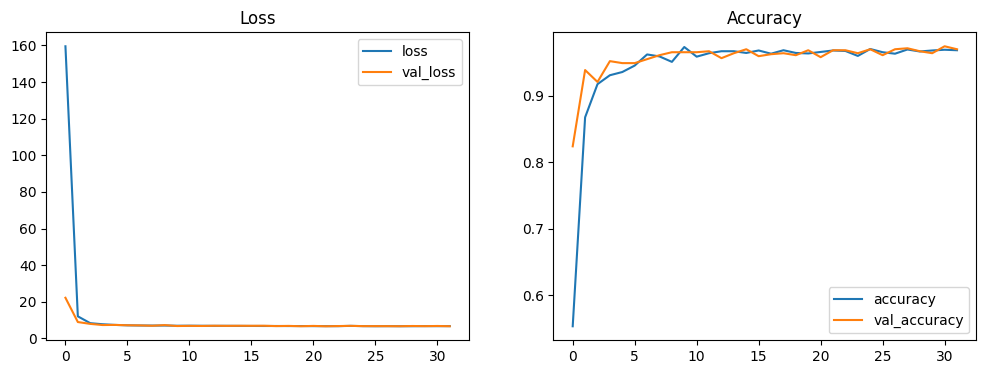

Fold 5 - Best validation loss: 6.6265869140625, Best validation accuracy: 0.9746646881103516


In [24]:
# Define the number of folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store results
fold_no = 1
histories = []
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Perform K-Fold Cross Validation
for train_index, val_index in kf.split(np.arange(len(k_fold_generator.filenames))):
    print(f"Training fold {fold_no}...")
    
    # Create a new model instance
    l1l2=tf.keras.regularizers.L1L2(l1=0.01, l2=0.01)

    # Build the model
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(150, 60, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l1l2),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Create data generators for the current fold
    train_data = np.array(k_fold_generator.filenames)[train_index]
    val_data = np.array(k_fold_generator.filenames)[val_index]
    
    train_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': train_data, 'class': [str(k_fold_generator.classes[i]) for i in train_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    val_fold_generator = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        pd.DataFrame({'filename': val_data, 'class': [str(k_fold_generator.classes[i]) for i in val_index]}),
        directory=train_dir,
        x_col='filename',
        y_col='class',
        target_size=(150, 60),
        batch_size=64,
        class_mode='categorical',
        color_mode="grayscale",
        shuffle=True
    )
    
    # Train the model
    history = model.fit(
        train_fold_generator,
        epochs=500,
        verbose=0,
        validation_data=val_fold_generator,
        callbacks=[early_stopping, plot_losses]
    )
    
    # Store the history
    histories.append(history)
    
    # Print fold results
    print(f"Fold {fold_no} - Best validation loss: {np.min(history.history['val_loss'])}, Best validation accuracy: {np.max(history.history['val_accuracy'])}")
    
    fold_no += 1

Fold 1 - Best validation loss: 6.700867652893066, Best validation accuracy: 0.976190447807312
Fold 2 - Best validation loss: 6.587381362915039, Best validation accuracy: 0.9836065769195557
Fold 3 - Best validation loss: 6.718803882598877, Best validation accuracy: 0.9776452779769897
Fold 4 - Best validation loss: 6.698113441467285, Best validation accuracy: 0.9895678162574768
Fold 5 - Best validation loss: 6.6265869140625, Best validation accuracy: 0.9746646881103516
Mean validation loss: 6.666350650787353, Std validation loss: 0.050535023536158144
Mean validation accuracy: 0.9803349614143372, Std validation accuracy: 0.005522906226658618


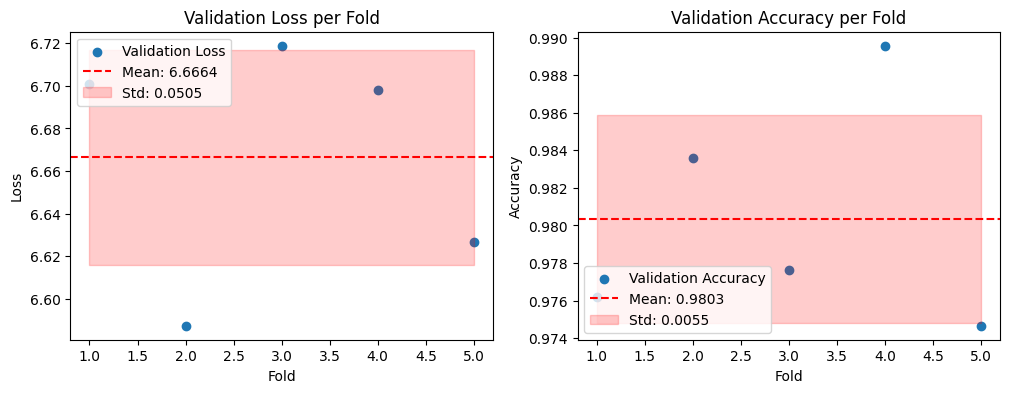

In [25]:
# Initialize lists to store the metrics
val_losses = []
val_accuracies = []

# Iterate through the histories and extract the metrics
for i, history in enumerate(histories):
    val_losses.append(np.min(history.history['val_loss']))
    val_accuracies.append(np.max(history.history['val_accuracy']))
    print(f"Fold {i+1} - Best validation loss: {val_losses[-1]}, Best validation accuracy: {val_accuracies[-1]}")

# Calculate mean and standard deviation
mean_val_loss = np.mean(val_losses)
std_val_loss = np.std(val_losses)
mean_val_accuracy = np.mean(val_accuracies)
std_val_accuracy = np.std(val_accuracies)

# Print mean and standard deviation
print(f"Mean validation loss: {mean_val_loss}, Std validation loss: {std_val_loss}")
print(f"Mean validation accuracy: {mean_val_accuracy}, Std validation accuracy: {std_val_accuracy}")

# Plot the metrics
plt.figure(figsize=(12, 4))

# Plot validation loss
plt.subplot(1, 2, 1)
plt.scatter(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.axhline(mean_val_loss, color='r', linestyle='--', label=f'Mean: {mean_val_loss:.4f}')
plt.fill_between(range(1, len(val_losses) + 1), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='r', alpha=0.2, label=f'Std: {std_val_loss:.4f}')
plt.title('Validation Loss per Fold')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.legend(loc='upper left')

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.scatter(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.axhline(mean_val_accuracy, color='r', linestyle='--', label=f'Mean: {mean_val_accuracy:.4f}')
plt.fill_between(range(1, len(val_accuracies) + 1), mean_val_accuracy - std_val_accuracy, mean_val_accuracy + std_val_accuracy, color='r', alpha=0.2, label=f'Std: {std_val_accuracy:.4f}')
plt.title('Validation Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend(loc='lower left')

plt.show()